# Root 2 Result Analysis

This notebook mirrors the earlier `results/1` submission analysis, but for the root trader run:

- `data/round 1/results/root_2/135666.json`
- `data/round 1/results/root_2/135666.log`

It focuses on three questions:

1. What happened in the live-style result?
2. How did the submitted root trader behave tick by tick?
3. Why did a strategy with only five fills still finish strongly positive at roughly `1581` XIRECS?


In [1]:
from __future__ import annotations

import importlib.util
import json
import sys
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from datamodel import Observation, OrderDepth, Trade, TradingState

sns.set_theme(style="whitegrid", context="talk")
pd.options.display.max_columns = 200

RESULT_JSON_PATH = ROOT / "data" / "round 1" / "results" / "root_2" / "135666.json"
RESULT_LOG_PATH = ROOT / "data" / "round 1" / "results" / "root_2" / "135666.log"
TRADER_PATH = ROOT / "src" / "imc_eda" / "round1" / "root" / "root_trader_2.py"

FIGURES_DIR = ROOT / "reports" / "figures" / "round1-root-2-analysis"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def nonzero_frame(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    cleaned = df.copy()
    for column in columns:
        if column in cleaned.columns:
            cleaned[column] = cleaned[column].where(cleaned[column].notna() & (cleaned[column] != 0), np.nan)
    return cleaned


In [2]:
result_json = json.loads(RESULT_JSON_PATH.read_text(encoding="utf-8"))
result_log = json.loads(RESULT_LOG_PATH.read_text(encoding="utf-8"))

activities = pd.read_csv(StringIO(result_json["activitiesLog"]), sep=";").sort_values(["timestamp", "product"]).reset_index(drop=True)
graph = pd.read_csv(StringIO(result_json["graphLog"]), sep=";").rename(columns={"value": "pnl"})
trade_history = pd.DataFrame(result_log["tradeHistory"]).sort_values(["timestamp", "symbol", "price"]).reset_index(drop=True)
submission_trades = trade_history[(trade_history["buyer"] == "SUBMISSION") | (trade_history["seller"] == "SUBMISSION")].copy()
submission_trades["side"] = np.where(submission_trades["buyer"] == "SUBMISSION", "buy", "sell")
submission_trades["signed_qty"] = np.where(submission_trades["buyer"] == "SUBMISSION", submission_trades["quantity"], -submission_trades["quantity"])
submission_trades["cash_flow"] = -submission_trades["signed_qty"] * submission_trades["price"]
submission_trades["cum_position"] = submission_trades["signed_qty"].cumsum()

summary = pd.DataFrame(
    [
        {
            "status": result_json["status"],
            "reported_profit": result_json["profit"],
            "total_market_trades": len(trade_history),
            "submission_trades": len(submission_trades),
            "submission_symbols": ", ".join(sorted(submission_trades["symbol"].unique().tolist())),
            "terminal_position": int(submission_trades["signed_qty"].sum()),
        }
    ]
)
display(summary)
display(submission_trades.groupby("symbol").agg(trades=("symbol", "size"), net_qty=("signed_qty", "sum"), cash=("cash_flow", "sum")).reset_index())
submission_trades


,status,reported_profit,total_market_trades,submission_trades,submission_symbols,terminal_position
0,FINISHED,1581.0,91,5,INTARIAN_PEPPER_ROOT,20


,symbol,trades,net_qty,cash
0,INTARIAN_PEPPER_ROOT,5,20,-240417.0


,timestamp,buyer,seller,symbol,currency,price,quantity,side,signed_qty,cash_flow,cum_position
13,19300,SUBMISSION,,INTARIAN_PEPPER_ROOT,XIRECS,12015.0,5,buy,5,-60075.0,5
16,20200,SUBMISSION,,INTARIAN_PEPPER_ROOT,XIRECS,12016.0,5,buy,5,-60080.0,10
18,21900,SUBMISSION,,INTARIAN_PEPPER_ROOT,XIRECS,12017.0,3,buy,3,-36051.0,13
27,29300,SUBMISSION,,INTARIAN_PEPPER_ROOT,XIRECS,12025.0,4,buy,4,-48100.0,17
29,31700,SUBMISSION,,INTARIAN_PEPPER_ROOT,XIRECS,12037.0,3,buy,3,-36111.0,20


## PnL Path

The run made its money early. A small cluster of pepper buys built a long position, and the rest of the session mostly rewarded that inventory as the market drifted higher.


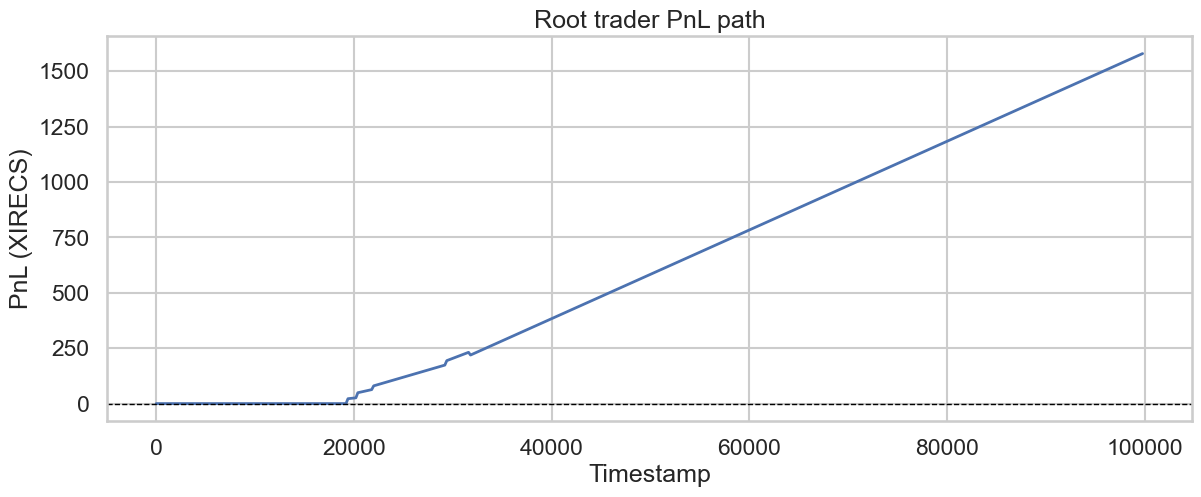

,timestamp,pnl
495,99000,1563.0
496,99200,1567.0
497,99400,1571.0
498,99600,1575.0
499,99800,1579.0


In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=graph, x="timestamp", y="pnl", ax=ax, linewidth=2)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Root trader PnL path")
ax.set_xlabel("Timestamp")
ax.set_ylabel("PnL (XIRECS)")
fig.savefig(FIGURES_DIR / "pnl-path.png", dpi=150, bbox_inches="tight")
plt.show()

graph.tail()


## Execution Footprint

Unlike the earlier mixed-product submission, this trader only filled in `INTARIAN_PEPPER_ROOT`, and every fill was a buy. The run ended long `20` units, so the outcome was driven much more by directional inventory than by repeated round trips.


,product,side,fills,avg_fill_vs_bid,avg_fill_vs_ask,avg_marked_pnl_at_fill
0,INTARIAN_PEPPER_ROOT,buy,5,2.0,2.4,99.5594


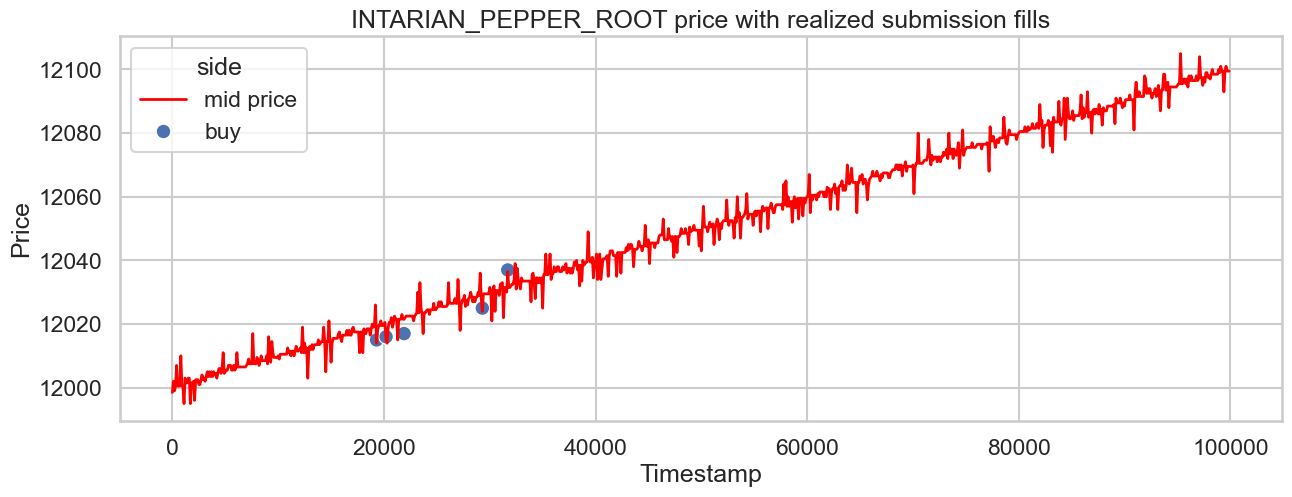

,timestamp,side,price,quantity,bid_price_1,ask_price_1,mid_price,fill_vs_bid,fill_vs_ask,profit_and_loss
0,19300,buy,12015.0,5,12013.0,12015.0,12014.0,2.0,0.0,0.000000
1,20200,buy,12016.0,5,12014.0,12016.0,12015.0,2.0,0.0,26.000000
2,21900,buy,12017.0,3,12015.0,12028.0,12021.5,2.0,11.0,64.000000
3,29300,buy,12025.0,4,12023.0,12025.0,12024.0,2.0,0.0,174.890625
4,31700,buy,12037.0,3,12035.0,12038.0,12036.5,2.0,1.0,232.906250


In [4]:
quote_columns = ["timestamp", "product", "bid_price_1", "ask_price_1", "mid_price", "profit_and_loss"]
executed = submission_trades.rename(columns={"symbol": "product"}).merge(activities[quote_columns], on=["timestamp", "product"], how="left")
executed["fill_vs_bid"] = executed["price"] - executed["bid_price_1"]
executed["fill_vs_ask"] = executed["ask_price_1"] - executed["price"]
executed["next_mid_change_1"] = executed["mid_price"].shift(-1) - executed["mid_price"]
executed["next_mid_change_5"] = executed["mid_price"].shift(-5) - executed["mid_price"]

display(
    executed.groupby(["product", "side"]).agg(
        fills=("product", "size"),
        avg_fill_vs_bid=("fill_vs_bid", "mean"),
        avg_fill_vs_ask=("fill_vs_ask", "mean"),
        avg_marked_pnl_at_fill=("profit_and_loss", "mean"),
    ).round(4).reset_index()
)

pepper_quotes = activities[activities["product"] == "INTARIAN_PEPPER_ROOT"].copy()
pepper_quotes_plot = nonzero_frame(pepper_quotes, ["bid_price_1", "ask_price_1", "mid_price"])
executed_plot = nonzero_frame(executed, ["price", "bid_price_1", "ask_price_1", "mid_price"])
fig, ax = plt.subplots(figsize=(15, 5))
sns.lineplot(data=pepper_quotes_plot, x="timestamp", y="mid_price", ax=ax, label="mid price", linewidth=2, color="red")
sns.scatterplot(data=executed_plot, x="timestamp", y="price", hue="side", style="side", s=110, ax=ax)
ax.set_title("INTARIAN_PEPPER_ROOT price with realized submission fills")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
fig.savefig(FIGURES_DIR / "pepper-fills.png", dpi=150, bbox_inches="tight")
plt.show()

executed[["timestamp", "side", "price", "quantity", "bid_price_1", "ask_price_1", "mid_price", "fill_vs_bid", "fill_vs_ask", "profit_and_loss"]]


## Inventory Risk

Because the fills were all buys, the main dynamic was long inventory accumulation. In this replay that concentration helped rather than hurt, because pepper continued to grind upward after most fills.


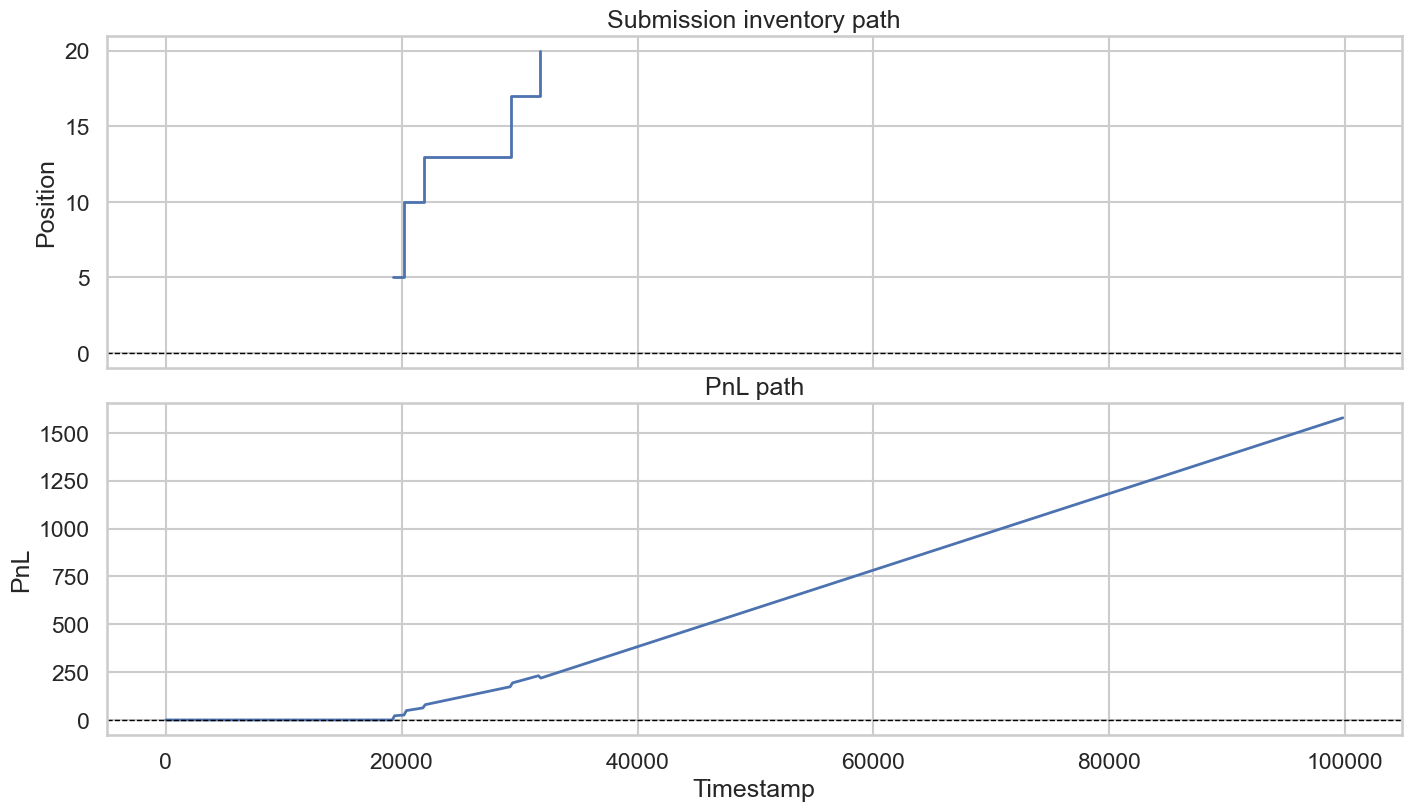

,timestamp,signed_qty,position
0,19300,5,5
1,20200,5,10
2,21900,3,13
3,29300,4,17
4,31700,3,20


In [5]:
inventory_path = executed[["timestamp", "signed_qty"]].copy()
inventory_path["position"] = inventory_path["signed_qty"].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, constrained_layout=True)
sns.stepplot = getattr(sns, "stepplot", None)

axes[0].step(inventory_path["timestamp"], inventory_path["position"], where="post", linewidth=2)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Submission inventory path")
axes[0].set_ylabel("Position")

sns.lineplot(data=graph, x="timestamp", y="pnl", ax=axes[1], linewidth=2)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("PnL path")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("PnL")

fig.savefig(FIGURES_DIR / "inventory-and-pnl.png", dpi=150, bbox_inches="tight")
plt.show()

inventory_path


## Replay The Submitted Root Trader

The root trader stores useful internal diagnostics in `traderData`, so replaying it lets us inspect:

- estimated fair value
- residual versus threshold
- signal direction
- buy/sell miss counters and aggression levels
- how often it tried to quote versus how often it actually filled


In [6]:
spec = importlib.util.spec_from_file_location("root_submission_trader_module", TRADER_PATH)
submission_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(submission_module)
Trader = submission_module.Trader

replay_trader = Trader()
trader_data = ""
replayed_rows = []

submission_trade_rows = submission_trades.to_dict("records")
own_trades_by_ts = {}
position_by_ts = {}
running_position = 0
for ts in sorted(activities["timestamp"].unique().tolist()):
    fills_this_ts = []
    for row in submission_trade_rows:
        if row["timestamp"] != ts:
            continue
        fills_this_ts.append(
            Trade(
                symbol=row["symbol"],
                price=int(row["price"]),
                quantity=int(row["quantity"]),
                buyer=row["buyer"],
                seller=row["seller"],
                timestamp=int(row["timestamp"]),
            )
        )
        running_position += int(row["signed_qty"])
    own_trades_by_ts[ts] = {"INTARIAN_PEPPER_ROOT": fills_this_ts} if fills_this_ts else {}
    position_by_ts[ts] = {"INTARIAN_PEPPER_ROOT": running_position} if running_position else {}

for ts, group in activities.groupby("timestamp", sort=True):
    order_depths = {}
    mid_price = np.nan
    for row in group.itertuples(index=False):
        depth = OrderDepth()
        for level in (1, 2, 3):
            bid_price = getattr(row, f"bid_price_{level}", np.nan)
            bid_volume = getattr(row, f"bid_volume_{level}", np.nan)
            ask_price = getattr(row, f"ask_price_{level}", np.nan)
            ask_volume = getattr(row, f"ask_volume_{level}", np.nan)
            if pd.notna(bid_price) and pd.notna(bid_volume):
                depth.buy_orders[int(bid_price)] = int(bid_volume)
            if pd.notna(ask_price) and pd.notna(ask_volume):
                depth.sell_orders[int(ask_price)] = -int(ask_volume)
        order_depths[row.product] = depth
        if row.product == "INTARIAN_PEPPER_ROOT":
            mid_price = row.mid_price

    state = TradingState(
        trader_data,
        int(ts),
        {},
        order_depths,
        own_trades_by_ts.get(ts, {}),
        {},
        position_by_ts.get(ts, {}),
        Observation({}, {}),
    )
    orders_by_product, _, trader_data = replay_trader.run(state)
    memory = json.loads(trader_data)
    pepper = memory.get("pepper", {})
    orders = orders_by_product.get("INTARIAN_PEPPER_ROOT", [])

    replayed_rows.append(
        {
            "timestamp": int(ts),
            "mid_price": mid_price,
            "signal": pepper.get("last_signal", 0),
            "action": pepper.get("last_action", "hold"),
            "sigma": pepper.get("last_sigma"),
            "residual": pepper.get("last_residual"),
            "adjusted_residual": pepper.get("last_adjusted_residual"),
            "fair_value": pepper.get("last_fair_value"),
            "upper_threshold": pepper.get("last_upper_threshold"),
            "lower_threshold": pepper.get("last_lower_threshold"),
            "buy_k": pepper.get("last_buy_k"),
            "sell_k": pepper.get("last_sell_k"),
            "buy_aggression_level": pepper.get("buy_aggression_level", 0),
            "sell_aggression_level": pepper.get("sell_aggression_level", 0),
            "buy_miss_count": pepper.get("buy_miss_count", 0),
            "sell_miss_count": pepper.get("sell_miss_count", 0),
            "position": position_by_ts.get(ts, {}).get("INTARIAN_PEPPER_ROOT", 0),
            "order_count": len(orders),
            "buy_orders": sum(1 for order in orders if order.quantity > 0),
            "sell_orders": sum(1 for order in orders if order.quantity < 0),
            "submitted_prices": [order.price for order in orders],
            "submitted_quantities": [order.quantity for order in orders],
        }
    )

replayed = pd.DataFrame(replayed_rows)
replay_summary = pd.DataFrame(
    [
        {
            "ticks": len(replayed),
            "ticks_with_orders": int((replayed["order_count"] > 0).sum()),
            "submitted_orders": int(replayed["order_count"].sum()),
            "buy_signal_share": float((replayed["signal"] > 0).mean()),
            "sell_signal_share": float((replayed["signal"] < 0).mean()),
            "realized_fills": len(submission_trades),
            "fill_per_submitted_order": float(len(submission_trades) / replayed["order_count"].sum()),
            "max_short_position": int(replayed["position"].min()),
        }
    ]
).round(4)

fill_action_by_ts = (
    executed.groupby("timestamp")["side"]
    .agg(lambda values: ", ".join(sorted(pd.unique(values))))
    .rename("realized_fill_action")
)

replayed = replayed.merge(fill_action_by_ts, on="timestamp", how="left")
replayed["realized_fill_action"] = replayed["realized_fill_action"].fillna("none")

for column in ["residual", "adjusted_residual", "lower_threshold", "upper_threshold", "buy_k", "sell_k", "sigma"]:
    replayed[column] = pd.to_numeric(replayed[column], errors="coerce")

threshold_ready = replayed[["adjusted_residual", "lower_threshold", "upper_threshold"]].notna().all(axis=1)
replayed["threshold_cross"] = "hold"
replayed.loc[
    threshold_ready & (replayed["adjusted_residual"] < replayed["lower_threshold"]),
    "threshold_cross",
] = "buy"
replayed.loc[
    threshold_ready & (replayed["adjusted_residual"] > replayed["upper_threshold"]),
    "threshold_cross",
] = "sell"
replayed["decision_match"] = replayed["threshold_cross"] == replayed["action"]

comparison_columns = [
    "timestamp",
    "residual",
    "adjusted_residual",
    "lower_threshold",
    "upper_threshold",
    "threshold_cross",
    "buy_k",
    "sell_k",
    "signal",
    "action",
    "realized_fill_action",
    "decision_match",
    "buy_orders",
    "sell_orders",
    "submitted_prices",
    "submitted_quantities",
]

comparison_view = replayed.loc[replayed["order_count"] > 0, comparison_columns].copy()
comparison_view[["residual", "adjusted_residual", "lower_threshold", "upper_threshold", "buy_k", "sell_k"]] = (
    comparison_view[["residual", "adjusted_residual", "lower_threshold", "upper_threshold", "buy_k", "sell_k"]].round(4)
)

signal_mismatch = replayed.loc[
    ((replayed["signal"] > 0) & (replayed["action"] != "buy"))
    | ((replayed["signal"] < 0) & (replayed["action"] != "sell")),
    comparison_columns,
].copy()

if not signal_mismatch.empty:
    signal_mismatch[["residual", "adjusted_residual", "lower_threshold", "upper_threshold", "buy_k", "sell_k"]] = (
        signal_mismatch[["residual", "adjusted_residual", "lower_threshold", "upper_threshold", "buy_k", "sell_k"]].round(4)
    )

action_decision_view = replayed.loc[
    (replayed["order_count"] > 0) | (replayed["realized_fill_action"] != "none"),
    comparison_columns,
].copy()
action_decision_view[["residual", "adjusted_residual", "lower_threshold", "upper_threshold", "buy_k", "sell_k"]] = (
    action_decision_view[["residual", "adjusted_residual", "lower_threshold", "upper_threshold", "buy_k", "sell_k"]].round(4)
)

fill_decision_view = replayed.loc[
    replayed["realized_fill_action"] != "none",
    comparison_columns,
].copy()
if not fill_decision_view.empty:
    fill_decision_view[["residual", "adjusted_residual", "lower_threshold", "upper_threshold", "buy_k", "sell_k"]] = (
        fill_decision_view[["residual", "adjusted_residual", "lower_threshold", "upper_threshold", "buy_k", "sell_k"]].round(4)
    )

display(replay_summary)
display(action_decision_view.head(20))
if not fill_decision_view.empty:
    display(fill_decision_view)
if not signal_mismatch.empty:
    display(signal_mismatch.head(15))


,ticks,ticks_with_orders,submitted_orders,buy_signal_share,sell_signal_share,realized_fills,fill_per_submitted_order,max_short_position
0,1000,120,120,0.818,0.008,5,0.0417,0


,timestamp,residual,adjusted_residual,lower_threshold,upper_threshold,threshold_cross,buy_k,sell_k,signal,action,realized_fill_action,decision_match,buy_orders,sell_orders,submitted_prices,submitted_quantities
18,1800,-1.1545,-1.1545,-1.1036,1.1036,buy,1.80,1.8,1,buy,none,True,1,0,[11995],[5]
90,9000,-1.2545,-1.2545,-1.1321,1.2350,buy,1.65,1.8,1,buy,none,True,1,0,[12000],[5]
144,14400,-1.4545,-1.4545,-1.2986,1.5583,buy,1.50,1.8,1,buy,none,True,1,0,[12010],[5]
146,14600,-1.2273,-1.2273,-1.2181,1.6241,buy,1.35,1.8,1,buy,none,True,1,0,[12007],[5]
159,15900,-1.2182,-1.2182,-1.1111,1.6666,buy,1.20,1.8,1,buy,none,True,1,0,[12011],[5]
160,16000,-1.6182,-1.6182,-1.0230,1.7538,buy,1.05,1.8,1,buy,none,True,1,0,[12008],[5]
168,16800,-1.0364,-1.0364,-0.8903,1.7807,buy,0.90,1.8,1,buy,none,True,1,0,[12012],[5]
169,16900,-0.8364,-0.8364,-0.7521,1.8050,buy,0.75,1.8,1,buy,none,True,1,0,[12012],[5]
172,17200,-0.6000,-0.6000,-0.4845,1.4535,buy,0.60,1.8,1,buy,none,True,1,0,[12013],[5]
173,17300,-0.4818,-0.4818,-0.4651,1.3953,buy,0.60,1.8,1,buy,none,True,1,0,[12013],[5]


,timestamp,residual,adjusted_residual,lower_threshold,upper_threshold,threshold_cross,buy_k,sell_k,signal,action,realized_fill_action,decision_match,buy_orders,sell_orders,submitted_prices,submitted_quantities
193,19300,-3.7000,-5.7000,-0.5925,1.7775,buy,0.6,1.8,1,buy,buy,True,1,0,[12015],[5]
202,20200,-4.4000,-8.4000,-0.8110,2.4329,buy,0.6,1.8,1,buy,buy,True,1,0,[12016],[5]
219,21900,-0.4091,-5.6091,-0.8824,2.6471,buy,0.6,1.8,1,buy,buy,True,1,0,[12017],[5]
293,29300,-3.3000,-10.1000,-0.6374,1.9122,buy,0.6,1.8,1,buy,buy,True,1,0,[12025],[3]
317,31700,3.2182,-4.7818,-0.7747,2.3240,buy,0.6,1.8,1,hold,buy,False,0,0,[],[]


,timestamp,residual,adjusted_residual,lower_threshold,upper_threshold,threshold_cross,buy_k,sell_k,signal,action,realized_fill_action,decision_match,buy_orders,sell_orders,submitted_prices,submitted_quantities
12,1200,1.4273,1.4273,-1.0988,1.0988,sell,1.80,1.8,-1,hold,none,False,0,0,[],[]
28,2800,1.3545,1.3545,-1.0777,1.1756,sell,1.65,1.8,-1,hold,none,False,0,0,[],[]
44,4400,1.3818,1.3818,-1.1679,1.2741,sell,1.65,1.8,-1,hold,none,False,0,0,[],[]
61,6100,3.3455,3.3455,-1.6123,1.7589,sell,1.65,1.8,-1,hold,none,False,0,0,[],[]
94,9400,4.0455,4.0455,-1.5766,1.8920,sell,1.50,1.8,-1,hold,none,False,0,0,[],[]
125,12500,1.4909,1.4909,-1.0704,1.2845,sell,1.50,1.8,-1,hold,none,False,0,0,[],[]
143,14300,2.8727,2.8727,-1.2695,1.5234,sell,1.50,1.8,-1,hold,none,False,0,0,[],[]
189,18900,1.2818,1.2818,-0.4124,1.2371,sell,0.60,1.8,-1,hold,none,False,0,0,[],[]
317,31700,3.2182,-4.7818,-0.7747,2.3240,buy,0.60,1.8,1,hold,buy,False,0,0,[],[]
318,31800,-1.5545,-9.5545,-0.8011,2.4033,buy,0.60,1.8,1,hold,none,False,0,0,[],[]


This strategy is a residual trader: it estimates a linear fair value, compares the current mid to that fair value, and acts once the adjusted residual crosses the live buy or sell threshold. The replay table below now puts the raw residual, adjusted residual, live buy/sell thresholds, threshold-cross verdict, submitted action, and realized fill side on the same row so we can see directly whether the algorithm thought it was worth buying or selling and what it actually did.

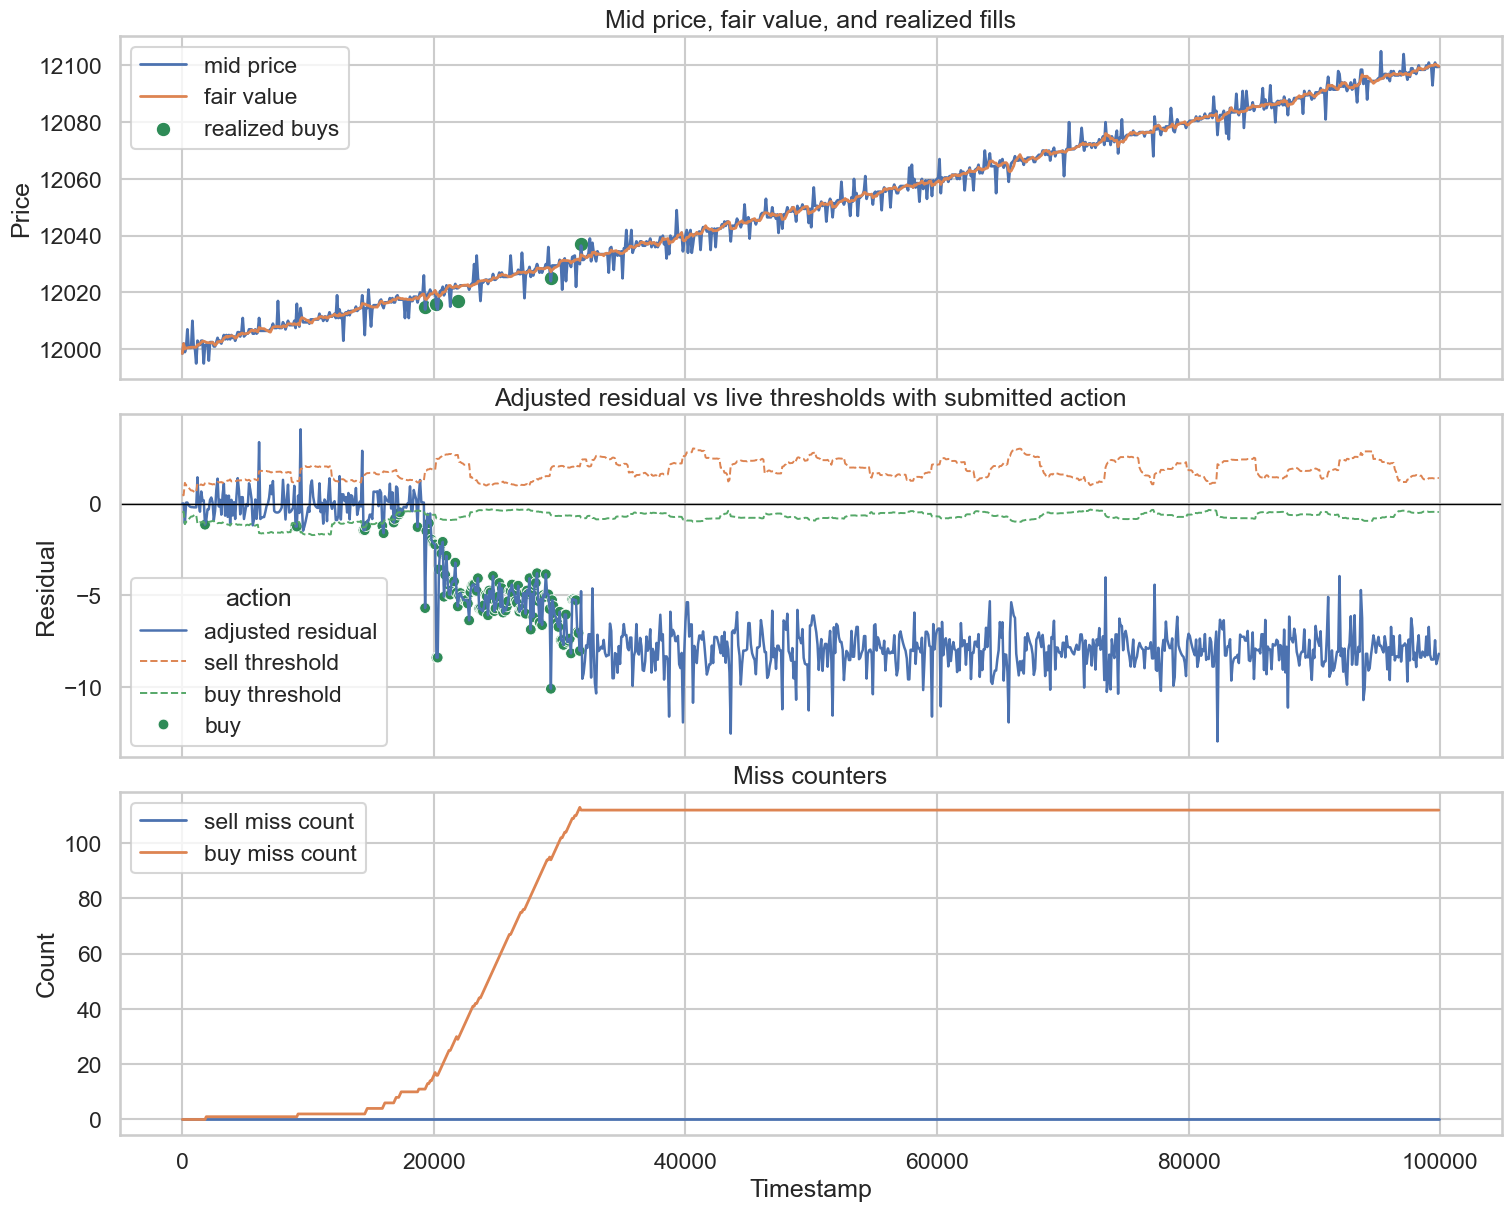

In [7]:
replayed_plot = nonzero_frame(replayed, ["mid_price", "fair_value"])
buy_points_plot = nonzero_frame(executed[executed["side"] == "buy"], ["price"])
sell_points_plot = nonzero_frame(executed[executed["side"] == "sell"], ["price"])
action_points = replayed.loc[replayed["action"] != "hold", ["timestamp", "adjusted_residual", "action"]].copy()

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True, constrained_layout=True)

sns.lineplot(data=replayed_plot, x="timestamp", y="mid_price", ax=axes[0], label="mid price", linewidth=2)
sns.lineplot(data=replayed_plot, x="timestamp", y="fair_value", ax=axes[0], label="fair value", linewidth=2)
if not buy_points_plot.empty:
    sns.scatterplot(data=buy_points_plot, x="timestamp", y="price", color="seagreen", s=110, ax=axes[0], label="realized buys")
if not sell_points_plot.empty:
    sns.scatterplot(data=sell_points_plot, x="timestamp", y="price", color="crimson", s=110, ax=axes[0], label="realized sells")
axes[0].set_title("Mid price, fair value, and realized fills")
axes[0].set_ylabel("Price")

sns.lineplot(data=replayed, x="timestamp", y="adjusted_residual", ax=axes[1], linewidth=1.8, label="adjusted residual")
sns.lineplot(data=replayed, x="timestamp", y="upper_threshold", ax=axes[1], linestyle="--", linewidth=1.4, label="sell threshold")
sns.lineplot(data=replayed, x="timestamp", y="lower_threshold", ax=axes[1], linestyle="--", linewidth=1.4, label="buy threshold")
if not action_points.empty:
    sns.scatterplot(
        data=action_points,
        x="timestamp",
        y="adjusted_residual",
        hue="action",
        palette={"buy": "seagreen", "sell": "crimson"},
        s=60,
        ax=axes[1],
        legend=True,
    )
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Adjusted residual vs live thresholds with submitted action")
axes[1].set_ylabel("Residual")

sns.lineplot(data=replayed, x="timestamp", y="sell_miss_count", ax=axes[2], label="sell miss count", linewidth=2)
sns.lineplot(data=replayed, x="timestamp", y="buy_miss_count", ax=axes[2], label="buy miss count", linewidth=2)
axes[2].set_title("Miss counters")
axes[2].set_xlabel("Timestamp")
axes[2].set_ylabel("Count")

fig.savefig(FIGURES_DIR / "signal-diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()


## Did Fills Help Or Hurt?

With only five fills, we can inspect each one directly and see whether the market moved in the trader's favor afterward.


,timestamp,side,price,quantity,mid_price,mid_change_1,mtm_pnl_1,mid_change_5,mtm_pnl_5,mid_change_10,mtm_pnl_10,mid_change_20,mtm_pnl_20
0,19300,buy,12015.0,5,12014.0,4.0,-20.0,5.5,-27.5,0.0,-0.0,1.0,-5.0
1,20200,buy,12016.0,5,12015.0,-1.0,5.0,7.0,-35.0,6.5,-32.5,7.5,-37.5
2,21900,buy,12017.0,3,12021.5,0.5,-1.5,1.0,-3.0,1.0,-3.0,2.0,-6.0
3,29300,buy,12025.0,4,12024.0,5.5,-22.0,5.5,-22.0,6.5,-26.0,-2.0,8.0
4,31700,buy,12037.0,3,12036.5,-5.0,15.0,-4.0,12.0,-2.5,7.5,-3.0,9.0


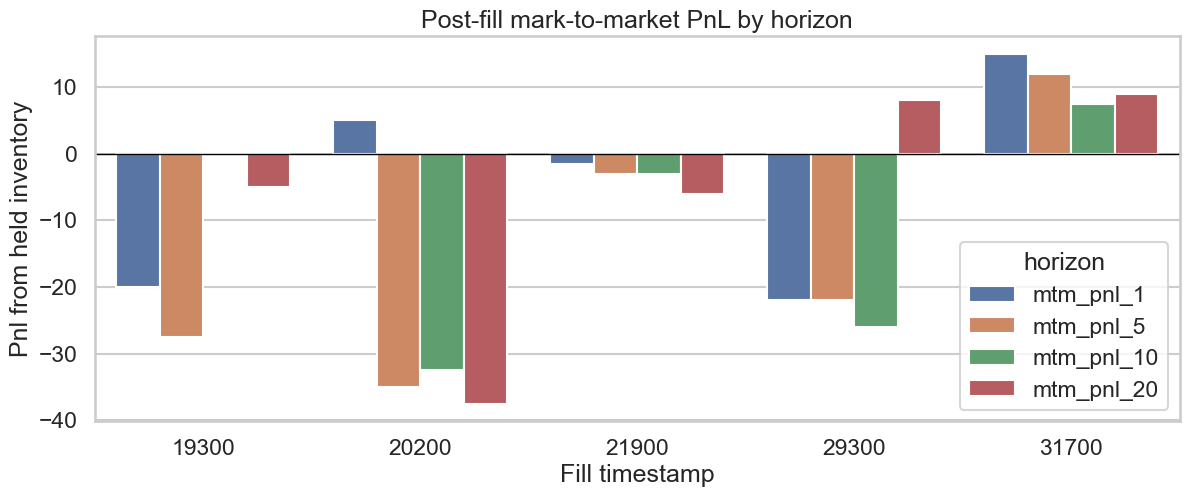

In [8]:
pepper_path = pepper_quotes[["timestamp", "mid_price"]].copy().reset_index(drop=True)
timestamp_to_index = {timestamp: index for index, timestamp in enumerate(pepper_path["timestamp"])}

rows = []
for row in executed.itertuples(index=False):
    idx = timestamp_to_index[row.timestamp]
    entry = {
        "timestamp": row.timestamp,
        "side": row.side,
        "price": row.price,
        "quantity": row.quantity,
        "mid_price": row.mid_price,
    }
    for horizon in (1, 5, 10, 20):
        future_idx = min(idx + horizon, len(pepper_path) - 1)
        future_mid = float(pepper_path.iloc[future_idx]["mid_price"])
        move = future_mid - row.mid_price
        entry[f"mid_change_{horizon}"] = move
        entry[f"mtm_pnl_{horizon}"] = -row.signed_qty * move
    rows.append(entry)

post_fill = pd.DataFrame(rows)
display(post_fill.round(4))

plot_post_fill = post_fill.melt(
    id_vars=["timestamp", "side", "price", "quantity"],
    value_vars=["mtm_pnl_1", "mtm_pnl_5", "mtm_pnl_10", "mtm_pnl_20"],
    var_name="horizon",
    value_name="mtm_pnl",
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=plot_post_fill, x="timestamp", y="mtm_pnl", hue="horizon", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Post-fill mark-to-market PnL by horizon")
ax.set_xlabel("Fill timestamp")
ax.set_ylabel("Pnl from held inventory")
fig.savefig(FIGURES_DIR / "post-fill-pnl.png", dpi=150, bbox_inches="tight")
plt.show()


## What Stands Out

The main story here is not execution failure but under-participation. The strategy found the right side of a rising pepper market, but with only five fills it captured just a small slice of the move and remained heavily dependent on one-sided inventory luck.


In [9]:
findings = [
    "1. The run finished positive at roughly `1581` XIRECS, with only five submission fills and all of them in `INTARIAN_PEPPER_ROOT`.",
    "2. Those five fills were all buys, building a terminal long position of `20`, so the result came from directional inventory exposure rather than frequent trading.",
    "3. Most buys printed at or very near the best ask, which suggests the fills came from joining or crossing into immediate offers rather than quietly accumulating on the bid.",
    "4. The replay still shows far more order attempts than fills, so fill scarcity remains the biggest structural limit on realized edge.",
    "5. Pepper trended upward after the entry cluster, so the long inventory was carried in the right regime and produced favorable marked PnL.",
    "6. The run worked, but it was narrow: one product, one side, five fills. That means the strategy still looks fragile if the next market regime reverses after entry.",
]

display(Markdown("\n".join(f"- {item}" for item in findings)))


- 1. The run finished positive at roughly `1581` XIRECS, with only five submission fills and all of them in `INTARIAN_PEPPER_ROOT`.
- 2. Those five fills were all buys, building a terminal long position of `20`, so the result came from directional inventory exposure rather than frequent trading.
- 3. Most buys printed at or very near the best ask, which suggests the fills came from joining or crossing into immediate offers rather than quietly accumulating on the bid.
- 4. The replay still shows far more order attempts than fills, so fill scarcity remains the biggest structural limit on realized edge.
- 5. Pepper trended upward after the entry cluster, so the long inventory was carried in the right regime and produced favorable marked PnL.
- 6. The run worked, but it was narrow: one product, one side, five fills. That means the strategy still looks fragile if the next market regime reverses after entry.

## Bottom Line

`results/root_2` was a low-activity but profitable run. The trader generated signals and did get paid for them, but the realized outcome was still extremely concentrated: only five pepper buys filled, those fills built a long `20`, and a strong upward market then carried the mark-to-market the rest of the way to roughly `+1581`.


## Key Learning Points And Next Changes

Key learning points:

- The model can get the direction right in pepper, and that is worth preserving.
- Realized PnL is still dominated by inventory luck because fill count is very low.
- A profitable long-only outcome is not enough evidence that the execution logic is robust across regimes.
- The notebook now reads more like a participation problem than a signal problem.

Necessary changes for the next attempt:

- Improve fill rate deliberately, especially when the signal is strong, without defaulting to always paying the full spread.
- Add clearer inventory management after entry so the trader can scale out, re-enter, or cut risk if the move stalls or reverses.
- Review why the run only participated on one side and confirm that sell-side logic is behaving as intended rather than being structurally too conservative.
- Stress-test the same logic on sessions where pepper reverses after the first fills, because this run benefited from a favorable trend after entry.
- Keep the replay diagnostics and use them to compare order attempts, aggression adjustments, and actual fills after each parameter change.
